# Oregon Wildfire Risk Prediction
### Graph Neural Network + Linear Regression — PyTorch & PyTorch Geometric

**Pipeline Overview**
1. Load and explore the merged fire + weather dataset (1970–2021)
2. Engineer spatial grid cells and aggregate features per cell per year
3. Build a spatial graph (nodes = grid cells, edges = geographic neighbors)
4. Train a GNN (GraphSAGE) to learn spatially-aware embeddings
5. Train a Linear Regression head on the embeddings to predict fire count / risk score
6. Run inference on the **most recent year (2021)** weather data
7. Export predicted fire risk per grid cell as **GeoJSON**

**Requirements**
```
pip install torch torch-geometric scikit-learn pandas numpy shapely geojson tqdm
```

In [1]:
# ── 0. Imports & Reproducibility ─────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import json
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam

from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

Using device: cpu
PyTorch version: 2.8.0


## 1 · Load Data

In [2]:
DATA_PATH = 'oregon_fires_weather_merged.csv'  # adjust path if needed

df = pd.read_csv(DATA_PATH, low_memory=False)
print(f'Shape: {df.shape}')
df.head(3)

Shape: (56280, 31)


,id,fire_year,report_date,county,latitude,longitude,total_acres,odf_acres,fuel_model,fuel_descr,...,WDSP,MXSPD,PRCP,PRCP_30DAY,VPD_PROXY,TEMP_RANGE,FIRE_SEASON,MONTH,DOY,STATION_USED
0,9151,1970,1970-06-15,Tillamook,45.517000,-122.047000,0.05,0.05,X,non-wildland fuel,...,6.9,10.1,0.0,0.0,8.4,10.9,1.0,6.0,166.0,9.999992e+10
1,9152,1970,1970-06-22,Tillamook,45.498172,-122.044483,0.75,0.75,X,non-wildland fuel,...,7.6,15.0,0.0,0.0,18.3,27.0,1.0,6.0,173.0,9.999992e+10
2,9153,1970,1970-06-24,Tillamook,45.748014,-122.044125,10.00,10.00,X,non-wildland fuel,...,7.1,10.1,0.0,0.0,18.6,29.9,1.0,6.0,175.0,9.999992e+10


In [3]:
# Basic info
print('Year range:', df['fire_year'].min(), '–', df['fire_year'].max())
print('Columns:', df.columns.tolist())
print('\nNull counts (selected):')
print(df[['latitude','longitude','TEMP','MAX','MIN','PRCP','VPD_PROXY','total_acres']].isnull().sum())

Year range: 1970 – 2021
Columns: ['id', 'fire_year', 'report_date', 'county', 'latitude', 'longitude', 'total_acres', 'odf_acres', 'fuel_model', 'fuel_descr', 'general_cause', 'fire_name', 'district', 'unit', 'legal', 'LATITUDE', 'LONGITUDE', 'TEMP', 'MAX', 'MIN', 'DEWP', 'WDSP', 'MXSPD', 'PRCP', 'PRCP_30DAY', 'VPD_PROXY', 'TEMP_RANGE', 'FIRE_SEASON', 'MONTH', 'DOY', 'STATION_USED']

Null counts (selected):
latitude          0
longitude         0
TEMP            234
MAX             234
MIN             234
PRCP            239
VPD_PROXY      1792
total_acres     119
dtype: int64


## 2 · Feature Engineering & Spatial Gridding

In [4]:
# ── 2a. Clean coordinates ──────────────────────────────────────────────────
df = df.dropna(subset=['latitude', 'longitude', 'fire_year'])
df['fire_year'] = df['fire_year'].astype(int)

# Oregon bounding box with a small buffer
LAT_MIN, LAT_MAX = 41.9, 46.3
LON_MIN, LON_MAX = -124.7, -116.4

df = df[
    df['latitude'].between(LAT_MIN, LAT_MAX) &
    df['longitude'].between(LON_MIN, LON_MAX)
].copy()
print(f'After bbox filter: {len(df):,} records')

After bbox filter: 55,101 records


In [5]:
# ── 2b. Assign each record to a 0.25° × 0.25° grid cell ───────────────────
GRID_RES = 0.25  # degrees

df['cell_lat'] = (np.floor(df['latitude']  / GRID_RES) * GRID_RES + GRID_RES / 2).round(4)
df['cell_lon'] = (np.floor(df['longitude'] / GRID_RES) * GRID_RES + GRID_RES / 2).round(4)
df['cell_id']  = df['cell_lat'].astype(str) + '_' + df['cell_lon'].astype(str)

print(f'Unique grid cells: {df["cell_id"].nunique()}')

Unique grid cells: 323


In [6]:
# ── 2c. Weather & fire features to aggregate ──────────────────────────────
WEATHER_FEATS = [
    'TEMP', 'MAX', 'MIN', 'DEWP', 'WDSP', 'MXSPD',
    'PRCP', 'PRCP_30DAY', 'VPD_PROXY', 'TEMP_RANGE'
]
# Fill missing weather values with column median
for col in WEATHER_FEATS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].fillna(df[col].median())

# Aggregate per (cell, year)
agg_dict = {feat: 'mean' for feat in WEATHER_FEATS if feat in df.columns}
agg_dict['id'] = 'count'          # fire count = label
agg_dict['total_acres'] = 'sum'   # total burned acres

grid_year = (
    df.groupby(['cell_id', 'cell_lat', 'cell_lon', 'fire_year'])
    .agg(agg_dict)
    .reset_index()
    .rename(columns={'id': 'fire_count'})
)

print(f'Grid-year records: {len(grid_year):,}')
grid_year.head(3)

Grid-year records: 10,671


,cell_id,cell_lat,cell_lon,fire_year,TEMP,MAX,MIN,DEWP,WDSP,MXSPD,PRCP,PRCP_30DAY,VPD_PROXY,TEMP_RANGE,fire_count,total_acres
0,41.875_-119.125,41.875,-119.125,2017,71.3,91.0,48.0,42.7,5.2,8.9,0.0,0.00,28.6,43.0,1,45690.00
1,41.875_-119.375,41.875,-119.375,2007,68.4,89.6,42.8,30.1,5.8,11.1,0.0,0.00,38.3,46.8,1,634.22
2,41.875_-119.625,41.875,-119.625,2012,68.0,86.0,44.6,38.2,6.8,11.1,0.0,0.01,29.8,41.4,1,0.25


## 3 · Build the Spatial Graph

In [7]:
# ── 3a. Node index per cell ────────────────────────────────────────────────
cells = (
    grid_year[['cell_id', 'cell_lat', 'cell_lon']]
    .drop_duplicates('cell_id')
    .reset_index(drop=True)
)
cells['node_idx'] = cells.index
cell_to_idx = dict(zip(cells['cell_id'], cells['node_idx']))

print(f'Number of nodes (grid cells): {len(cells)}')

Number of nodes (grid cells): 323


In [8]:
# ── 3b. Edges: connect cells whose centers are within 2 * GRID_RES distance
#         (i.e., 8-neighbor connectivity at 0.25° resolution)
def haversine_deg(lat1, lon1, lat2, lon2):
    """Approximate distance in degrees (good enough for neighbor detection)."""
    return math.sqrt((lat1 - lat2) ** 2 + (lon1 - lon2) ** 2)

EDGE_DIST = GRID_RES * 1.5  # connects 8-neighbors (diagonal included)

lats = cells['cell_lat'].values
lons = cells['cell_lon'].values
n = len(cells)

edge_src, edge_dst = [], []
for i in range(n):
    for j in range(i + 1, n):
        if abs(lats[i] - lats[j]) <= EDGE_DIST and abs(lons[i] - lons[j]) <= EDGE_DIST:
            if haversine_deg(lats[i], lons[i], lats[j], lons[j]) <= EDGE_DIST:
                edge_src += [i, j]
                edge_dst += [j, i]

edge_index = torch.tensor([edge_src, edge_dst], dtype=torch.long)
print(f'Edges: {edge_index.shape[1]:,} (undirected pairs × 2)')

Edges: 2,062 (undirected pairs × 2)


## 4 · Prepare Train / Validation Tensors

In [9]:
TARGET_YEAR = int(grid_year['fire_year'].max())
TRAIN_YEARS = sorted(grid_year['fire_year'].unique())
TRAIN_YEARS_EXCL = [y for y in TRAIN_YEARS if y < TARGET_YEAR]

print(f'Target (inference) year : {TARGET_YEAR}')
print(f'Training years          : {TRAIN_YEARS_EXCL[0]}–{TRAIN_YEARS_EXCL[-1]}')

Target (inference) year : 2021
Training years          : 1970–2020


In [10]:
FEAT_COLS = [c for c in WEATHER_FEATS if c in grid_year.columns]

def build_node_features(year_df):
    """Return an (n_nodes × n_feats) array aligned to cells.node_idx."""
    merged = cells[['cell_id', 'node_idx']].merge(
        year_df[['cell_id'] + FEAT_COLS + ['fire_count']],
        on='cell_id', how='left'
    ).sort_values('node_idx')
    # Fill cells with no fire record in that year with 0 fires and median weather
    X = merged[FEAT_COLS].fillna(merged[FEAT_COLS].median()).values.astype(np.float32)
    y = merged['fire_count'].fillna(0).values.astype(np.float32)
    return X, y

# --- Collect all training snapshots ---
X_train_all, y_train_all = [], []
for yr in TRAIN_YEARS_EXCL:
    yr_df = grid_year[grid_year['fire_year'] == yr]
    X, y = build_node_features(yr_df)
    X_train_all.append(X)
    y_train_all.append(y)

# Stack: shape (n_years * n_nodes, n_feats)
X_train_np = np.vstack(X_train_all)
y_train_np = np.concatenate(y_train_all)

# --- Target year ---
target_yr_df = grid_year[grid_year['fire_year'] == TARGET_YEAR]
X_target_np, y_target_np = build_node_features(target_yr_df)

print(f'Train  X shape: {X_train_np.shape}, y shape: {y_train_np.shape}')
print(f'Target X shape: {X_target_np.shape}')

Train  X shape: (16473, 10), y shape: (16473,)
Target X shape: (323, 10)


In [11]:
# ── Scale features ────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_np)
X_target_scaled = scaler.transform(X_target_np)

## 5 · GNN Model (GraphSAGE Encoder)

In [12]:
class WildfireGNN(nn.Module):
    """
    Two-layer GraphSAGE encoder.
    Input  : (n_nodes, n_input_feats)
    Output : (n_nodes, embed_dim)  — spatially-smoothed embeddings
    """
    def __init__(self, in_channels: int, hidden: int = 64, embed_dim: int = 32):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden)
        self.conv2 = SAGEConv(hidden, embed_dim)
        self.bn1   = nn.BatchNorm1d(hidden)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x  # (n_nodes, embed_dim)

N_FEATS    = X_train_scaled.shape[1]
HIDDEN_DIM = 64
EMBED_DIM  = 32

gnn = WildfireGNN(N_FEATS, HIDDEN_DIM, EMBED_DIM).to(DEVICE)
print(gnn)

WildfireGNN(
  (conv1): SAGEConv(10, 64, aggr=mean)
  (conv2): SAGEConv(64, 32, aggr=mean)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.2, inplace=False)
)


Pre-training GNN (graph autoencoder) …
  Epoch  50 | Recon Loss: 0.1456
  Epoch 100 | Recon Loss: 0.1419
  Epoch 150 | Recon Loss: 0.1378
  Epoch 200 | Recon Loss: 0.1342


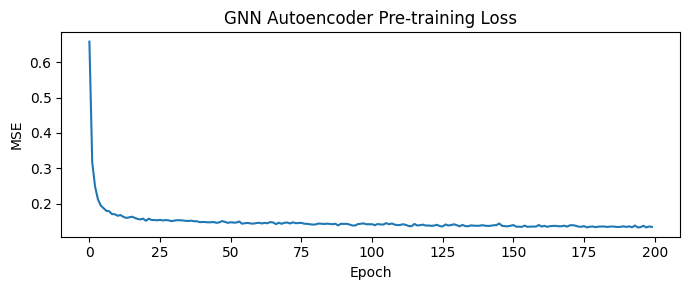

In [13]:
# ── Unsupervised pre-training via graph autoencoder (reconstruct node feats)
# This gives us meaningful embeddings even without per-year ground truth labels.

decoder = nn.Linear(EMBED_DIM, N_FEATS).to(DEVICE)
optimizer_ae = Adam(list(gnn.parameters()) + list(decoder.parameters()), lr=1e-3)

n_nodes = len(cells)
pretrain_losses = []

print('Pre-training GNN (graph autoencoder) …')
for epoch in range(1, 201):
    epoch_loss = 0.0
    # Iterate over each training year snapshot
    for X_yr in X_train_all:
        x_t  = torch.tensor(scaler.transform(X_yr), dtype=torch.float32).to(DEVICE)
        ei_t = edge_index.to(DEVICE)

        gnn.train(); decoder.train()
        optimizer_ae.zero_grad()
        emb  = gnn(x_t, ei_t)
        recon = decoder(emb)
        loss  = F.mse_loss(recon, x_t)
        loss.backward()
        optimizer_ae.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(X_train_all)
    pretrain_losses.append(avg_loss)
    if epoch % 50 == 0:
        print(f'  Epoch {epoch:3d} | Recon Loss: {avg_loss:.4f}')

plt.figure(figsize=(7, 3))
plt.plot(pretrain_losses)
plt.title('GNN Autoencoder Pre-training Loss')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.tight_layout(); plt.show()

## 6 · Extract GNN Embeddings & Train Linear Regression Head

In [14]:
def get_embeddings(X_np):
    """Run GNN on a single snapshot and return numpy embeddings."""
    gnn.eval()
    with torch.no_grad():
        x_t  = torch.tensor(X_np, dtype=torch.float32).to(DEVICE)
        ei_t = edge_index.to(DEVICE)
        emb  = gnn(x_t, ei_t)
    return emb.cpu().numpy()

# Build training embedding matrix: (n_years * n_nodes, embed_dim)
emb_list = [get_embeddings(scaler.transform(X)) for X in X_train_all]
E_train  = np.vstack(emb_list)   # (n_years * n_nodes, embed_dim)

# Target labels (fire counts per node per year, stacked)
y_train_full = np.concatenate(y_train_all)

print(f'Embedding matrix shape : {E_train.shape}')
print(f'Label vector shape     : {y_train_full.shape}')

Embedding matrix shape : (16473, 32)
Label vector shape     : (16473,)


In [15]:
# ── Linear Regression (Ridge) on embeddings ───────────────────────────────
reg = Ridge(alpha=1.0)
reg.fit(E_train, y_train_full)

y_pred_train = reg.predict(E_train)
rmse_train   = math.sqrt(mean_squared_error(y_train_full, y_pred_train))
r2_train     = r2_score(y_train_full, y_pred_train)

print(f'Train RMSE : {rmse_train:.4f}')
print(f'Train R²   : {r2_train:.4f}')

Train RMSE : 5.2757
Train R²   : 0.0775


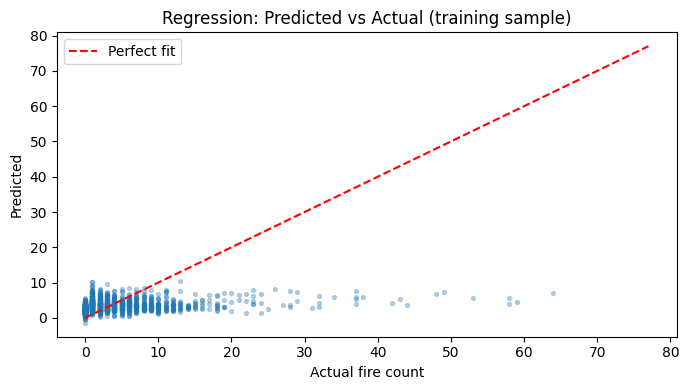

In [16]:
# Visual: predicted vs actual (training set sample)
plt.figure(figsize=(7, 4))
sample_idx = np.random.choice(len(y_train_full), size=min(2000, len(y_train_full)), replace=False)
plt.scatter(y_train_full[sample_idx], y_pred_train[sample_idx], alpha=0.3, s=8)
plt.plot([0, y_train_full.max()], [0, y_train_full.max()], 'r--', label='Perfect fit')
plt.xlabel('Actual fire count'); plt.ylabel('Predicted')
plt.title('Regression: Predicted vs Actual (training sample)')
plt.legend(); plt.tight_layout(); plt.show()

## 7 · Inference on Target Year (2021)

In [17]:
E_target   = get_embeddings(X_target_scaled)          # (n_nodes, embed_dim)
y_pred_raw = reg.predict(E_target)                    # raw predictions
y_pred     = np.clip(y_pred_raw, 0, None)             # fire count >= 0

# Normalize to 0-100 risk score for interpretability
risk_score = 100.0 * y_pred / (y_pred.max() + 1e-9)

print(f'Predicted fire counts  — min: {y_pred.min():.2f}  max: {y_pred.max():.2f}  mean: {y_pred.mean():.2f}')
print(f'Risk score (0–100)     — min: {risk_score.min():.1f}  max: {risk_score.max():.1f}  mean: {risk_score.mean():.1f}')

Predicted fire counts  — min: 2.36  max: 10.91  mean: 5.99
Risk score (0–100)     — min: 21.7  max: 100.0  mean: 54.9


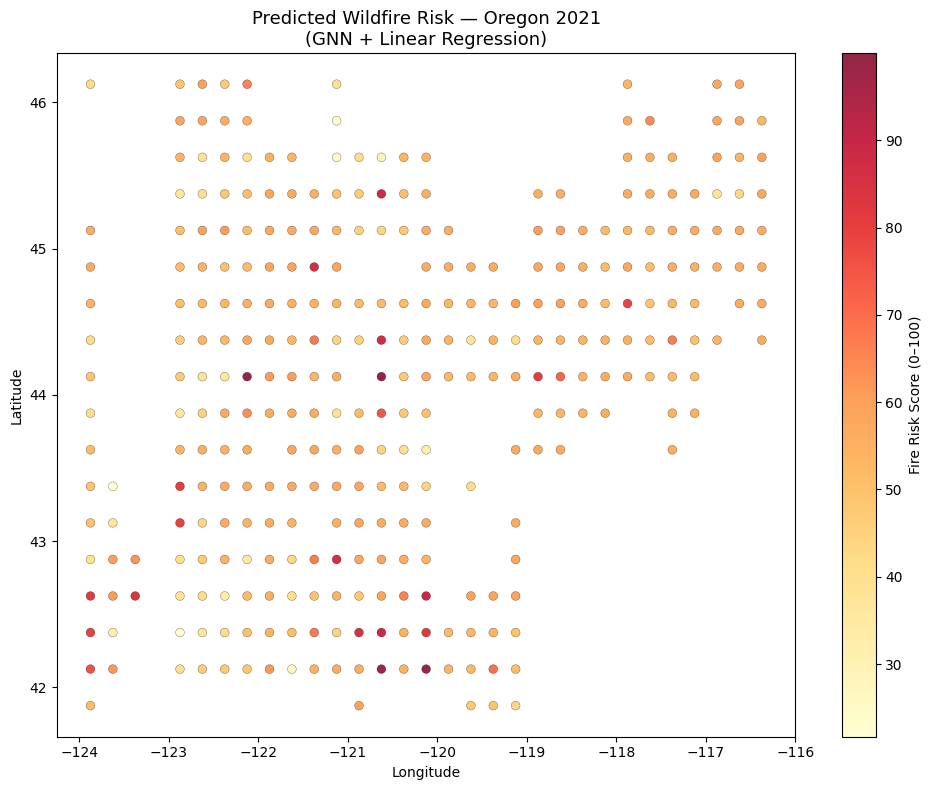

In [18]:
# Quick map of risk scores
result_df = cells[['cell_lat', 'cell_lon']].copy()
result_df['predicted_fires'] = y_pred
result_df['risk_score']      = risk_score

plt.figure(figsize=(10, 8))
sc = plt.scatter(
    result_df['cell_lon'], result_df['cell_lat'],
    c=result_df['risk_score'], cmap='YlOrRd',
    s=40, alpha=0.85, edgecolors='k', linewidths=0.2
)
plt.colorbar(sc, label='Fire Risk Score (0–100)')
plt.title(f'Predicted Wildfire Risk — Oregon {TARGET_YEAR}\n(GNN + Linear Regression)', fontsize=13)
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.tight_layout(); plt.show()

## 8 · Export GeoJSON

In [19]:
def build_cell_polygon(center_lat, center_lon, res=GRID_RES):
    """Return a GeoJSON Polygon for a single grid cell."""
    half = res / 2
    min_lon = center_lon - half
    max_lon = center_lon + half
    min_lat = center_lat - half
    max_lat = center_lat + half
    coords = [
        [min_lon, min_lat],
        [max_lon, min_lat],
        [max_lon, max_lat],
        [min_lon, max_lat],
        [min_lon, min_lat]   # close ring
    ]
    return {"type": "Polygon", "coordinates": [coords]}


features = []
for _, row in result_df.iterrows():
    feat = {
        "type": "Feature",
        "geometry": build_cell_polygon(row['cell_lat'], row['cell_lon']),
        "properties": {
            "center_lat"      : round(float(row['cell_lat']), 5),
            "center_lon"      : round(float(row['cell_lon']), 5),
            "predicted_fires" : round(float(row['predicted_fires']), 3),
            "risk_score"      : round(float(row['risk_score']), 2),
            "risk_category"   : (
                "Very High" if row['risk_score'] >= 75 else
                "High"      if row['risk_score'] >= 50 else
                "Medium"    if row['risk_score'] >= 25 else
                "Low"
            ),
            "prediction_year" : TARGET_YEAR,
            "model"           : "GNN (GraphSAGE) + Ridge Regression"
        }
    }
    features.append(feat)

geojson_obj = {
    "type": "FeatureCollection",
    "name": f"Oregon Wildfire Risk {TARGET_YEAR}",
    "metadata": {
        "description": "Predicted wildfire risk for Oregon grid cells.",
        "target_year" : TARGET_YEAR,
        "grid_res_deg": GRID_RES,
        "model"       : "GraphSAGE GNN encoder + Ridge Regression head",
        "n_cells"     : len(features),
        "risk_score"  : "0 (lowest) – 100 (highest)"
    },
    "features": features
}

OUTPUT_PATH = f'oregon_wildfire_risk_{TARGET_YEAR}.geojson'
with open(OUTPUT_PATH, 'w') as f:
    json.dump(geojson_obj, f, indent=2)

print(f'✅  GeoJSON saved → {OUTPUT_PATH}')
print(f'   Features written : {len(features)}')
print(f'   File size        : {Path(OUTPUT_PATH).stat().st_size / 1024:.1f} KB')

✅  GeoJSON saved → oregon_wildfire_risk_2021.geojson
   Features written : 323
   File size        : 247.2 KB


## 9 · Summary & Next Steps

| Step | Detail |
|------|--------|
| Spatial resolution | 0.25° × 0.25° grid cells |
| Training years | 1970–2020 |
| Inference year | 2021 |
| GNN architecture | 2-layer GraphSAGE with 8-neighbor graph |
| Regression head | Ridge Regression on 32-dim embeddings |
| Output | GeoJSON with `risk_score` (0–100) per cell |

**Possible improvements**
- Add terrain features (elevation, slope, aspect) as static node attributes
- Use a supervised GNN loss (predict fire count directly) instead of the autoencoder pre-training
- Incorporate temporal edges (connect same cell across consecutive years) for a spatio-temporal GNN
- Use a GATConv (attention) or GCNConv layer for comparison
- Visualize results interactively with [Folium](https://python-visualization.github.io/folium/) or [Kepler.gl](https://kepler.gl/)